In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    roc_auc_score, accuracy_score, log_loss,
    roc_curve, confusion_matrix, classification_report
)
from sklearn.utils.class_weight import compute_class_weight


ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/workspaces/DECLINE/.venv/lib/python3.12/site-packages/traitlets/traitlets.py", line 632, in get
    value = obj._trait_values[self.name]
            ~~~~~~~~~~~~~~~~~^^^^^^^^^^^
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/workspaces/DECLINE/.venv/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/workspaces/DECLINE/.venv/lib/python3.12/site-packages/ipykernel/kernelbase.py", line 340, in dispatch_control
    async with self._control_lock:
               ^^^^^^^^^^^^^^^^^^
  File "/workspaces/DECLINE/.venv/lib/python3.12/site-packages/traitlets/traitlets.py", line 687, in __get__
    return t.cast(G, self.get(obj, cls))  # the G should encode the Optional
                     ^^^^^^^^^^^^^^^^^^
  File "/workspaces/DECLINE/.venv/lib/p

In [2]:
data = pd.read_csv("clean.csv")

data["Has_Anxiety"] = (data["Anxiety Level (1-10)"] >= 5).astype(int)

X = data.drop(["Anxiety Level (1-10)", "Has_Anxiety"], axis=1)
y = data["Has_Anxiety"]


In [3]:
cat_cols = ["Gender", "Occupation"]
num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ]
)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [5]:
X_train_proc = preprocess.fit_transform(X_train)
X_test_proc = preprocess.transform(X_test)

input_dim = X_train_proc.shape[1]
print("Input features:", input_dim)


Input features: 30


In [6]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(zip(np.unique(y_train), class_weights))
print("Class weights:", class_weight_dict)


Class weights: {np.int64(0): np.float64(0.7220216606498195), np.int64(1): np.float64(1.6260162601626016)}


In [7]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(input_dim,)),
    
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    
    tf.keras.layers.Dense(1, activation="sigmoid")
])


2026-02-03 09:30:23.512582: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.BinaryAccuracy(name="accuracy")
    ]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    X_train_proc,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )
    ],
    verbose=1
)


Epoch 1/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7493 - auc: 0.8350 - loss: 0.4930 - val_accuracy: 0.8119 - val_auc: 0.9011 - val_loss: 0.3932
Epoch 2/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8026 - auc: 0.8893 - loss: 0.4145 - val_accuracy: 0.8119 - val_auc: 0.9046 - val_loss: 0.3887
Epoch 3/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8062 - auc: 0.8955 - loss: 0.4029 - val_accuracy: 0.8114 - val_auc: 0.9050 - val_loss: 0.3881
Epoch 4/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8107 - auc: 0.9003 - loss: 0.3940 - val_accuracy: 0.8045 - val_auc: 0.9047 - val_loss: 0.3921
Epoch 5/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8112 - auc: 0.9006 - loss: 0.3931 - val_accuracy: 0.8062 - val_auc: 0.9061 - val_loss: 0.3902
Epoch 6/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8104 - auc: 0.9034 - loss: 0.3878 - val_accuracy: 0.8131 - val_auc: 0.9061 - val_loss: 0.3806
Epoch 7/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 

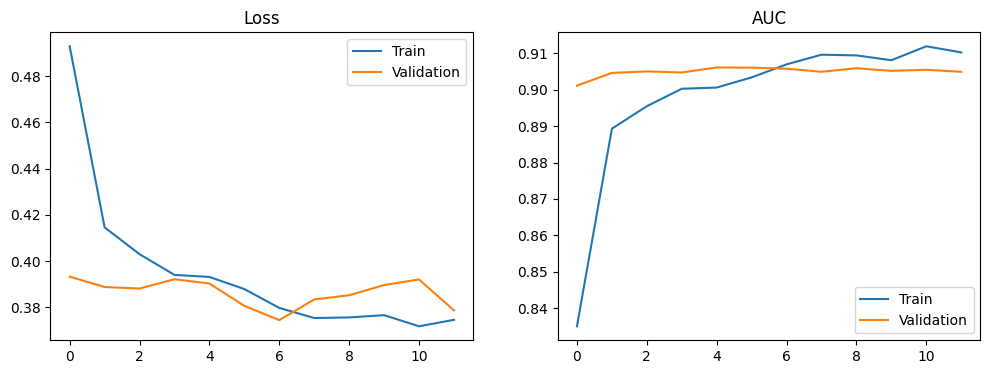

In [10]:
plt.figure(figsize=(12, 4))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss")
plt.legend()

# AUC
plt.subplot(1, 2, 2)
plt.plot(history.history["auc"], label="Train")
plt.plot(history.history["val_auc"], label="Validation")
plt.title("AUC")
plt.legend()

plt.show()


In [11]:
y_prob = model.predict(X_test_proc).ravel()


69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [12]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
best_threshold = thresholds[np.argmax(tpr - fpr)]

print(f"Optimal threshold: {best_threshold:.4f}")

y_pred = (y_prob >= best_threshold).astype(int)


Optimal threshold: 0.4663


In [13]:
print("Neural Network Performance")
print("---------------------------")
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob):.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Log Loss: {log_loss(y_test, y_prob):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Neural Network Performance
---------------------------
ROC-AUC : 0.8936
Accuracy: 0.8018
Log Loss: 0.3881

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.79      0.85      1524
           1       0.64      0.83      0.72       676

    accuracy                           0.80      2200
   macro avg       0.77      0.81      0.78      2200
weighted avg       0.83      0.80      0.81      2200



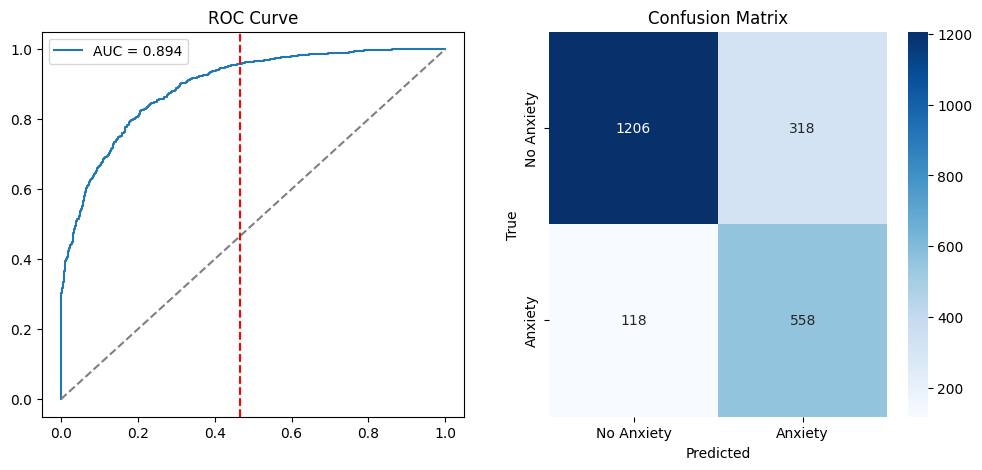

In [14]:
plt.figure(figsize=(12, 5))

# ROC
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.axvline(best_threshold, color="red", linestyle="--")
plt.title("ROC Curve")
plt.legend()

# Confusion Matrix
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Anxiety", "Anxiety"],
            yticklabels=["No Anxiety", "Anxiety"])
plt.title("Confusion Matrix")
plt.ylabel("True")
plt.xlabel("Predicted")

plt.show()
